<a href="https://colab.research.google.com/github/EzequielMovia/machine-learning-projects/blob/main/titanic-survival-ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praáctica de Red Neuronal "Clasificacion"

In [ ]:
#Librerías
import pandas as pd
#Sirve para trabajar con tablas y cargar el dataset.

import numpy as np
#Se usa para operaciones matemáticas y arreglos.

# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import RobustScaler,StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, classification_report

from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings("ignore")
from sklearn.neural_network import MLPClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'titanic' in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/practica_titanic.ipynb
/content/drive/MyDrive/carpeta_practica/Titanic-Dataset.csv


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/carpeta_practica/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

***Chequear si en la base existen datos nulos***

In [ ]:
print(df.isnull().sum())
print((df.isnull().sum() / len(df) * 100).round(2)) # este codigo agrega el procentaje tambien

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


In [ ]:
# Eliminamos Cabin por demasiados nulos
df = df.drop(columns=['Cabin'])

# Rellenamos Age con la mediana
df['Age'].fillna(df['Age'].median(), inplace=True)

# Rellenamos Embarked con la moda
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Verificamos que no queden nulos
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# Eliminamos columnas que no aportan información útil
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

print(df.shape)
print(df.columns.tolist())

(891, 8)
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


✅ Nulos → detectamos 3 columnas con nulos
✅ Limpieza → eliminamos Cabin (77%), rellenamos Age con mediana y Embarked con moda
✅ Eliminamos columnas inútiles → PassengerId, Name, Ticket
✅ Identificamos categóricas → Sex y Embarked

EDA


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [ ]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


la torta de sobrevivientes vs no sobrevivientes, igual que hicimos con fraude vs no fraude:

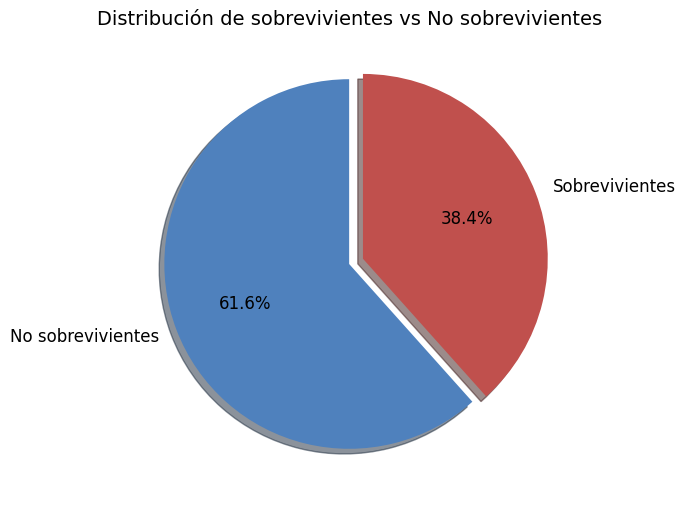

,Cantidad,Porcentaje (%)
Survived,,
0,549,61.62
1,342,38.38


In [ ]:
# Distribucion de la variable objetivo
valores = df['Survived'].value_counts()
porcentajes = df['Survived'].value_counts(normalize=True) * 100

# Colores
colores = ['#4F81BD', '#C0504D']

# Grafico de torta
plt.figure(figsize=(7,6))

plt.pie(valores,
        labels=['No sobrevivientes', 'Sobrevivientes'],
        autopct='%1.1f%%',
        startangle=90,
        colors=colores,
        explode=(0, 0.08),
        shadow=True,
        textprops={'fontsize':12})

plt.title('Distribución de sobrevivientes vs No sobrevivientes', fontsize=14)
plt.show()

# Tabla resumen
resumen = pd.DataFrame({
    'Cantidad': valores,
    'Porcentaje (%)': porcentajes.round(2)
})

display(resumen)

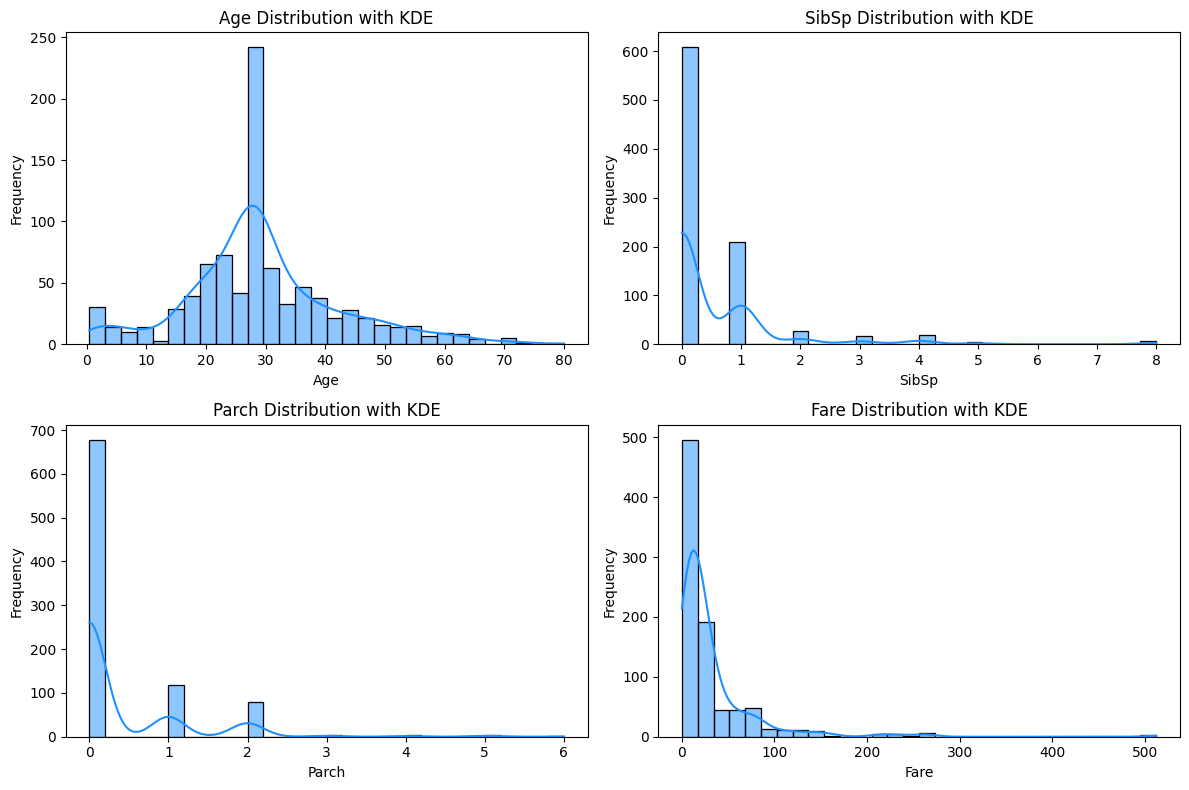

In [ ]:
# Histogramas con KDE para variables numéricas
columns_to_analyze = ['Age', 'SibSp', 'Parch', 'Fare']

def univariate_analysis(data, columns):
    plt.figure(figsize=(12, 8))
    for i, column in enumerate(columns, 1):
        plt.subplot(2, 2, i)
        sns.histplot(data[column], kde=True, bins=30, color='dodgerblue')
        plt.title(f'{column} Distribution with KDE')
        plt.xlabel(column)
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

univariate_analysis(df, columns_to_analyze)

# Distribucion de variables categoricas

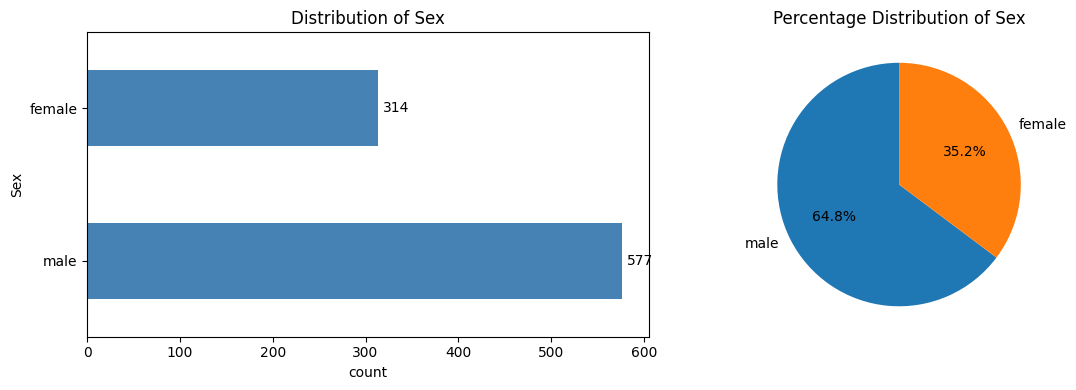

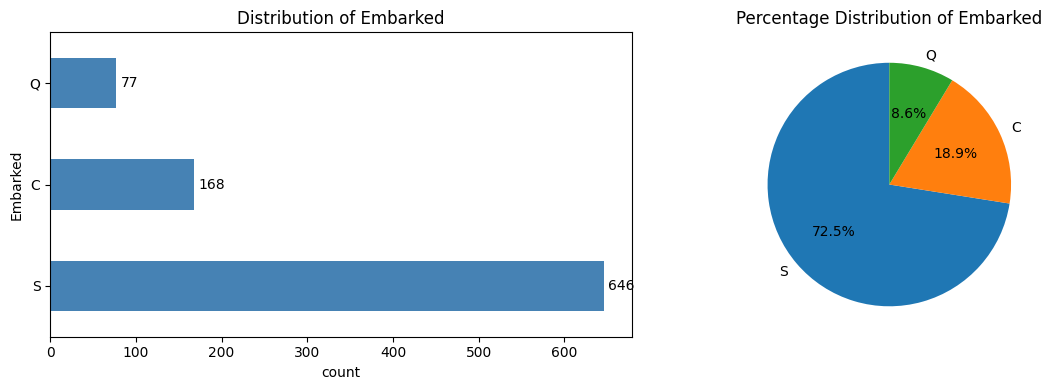

In [ ]:
# Distribución de variables categóricas
categoricas = ['Sex', 'Embarked']

for col in categoricas:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    valores = df[col].value_counts()

    # Barras horizontales
    valores.plot(kind='barh', ax=ax1, color='steelblue')
    for i, v in enumerate(valores):
        ax1.text(v + 5, i, str(v), va='center')
    ax1.set_title(f'Distribution of {col}')
    ax1.set_xlabel('count')

    # Torta
    ax2.pie(valores, labels=valores.index, autopct='%1.1f%%', startangle=90)
    ax2.set_title(f'Percentage Distribution of {col}')

    plt.tight_layout()
    plt.show()

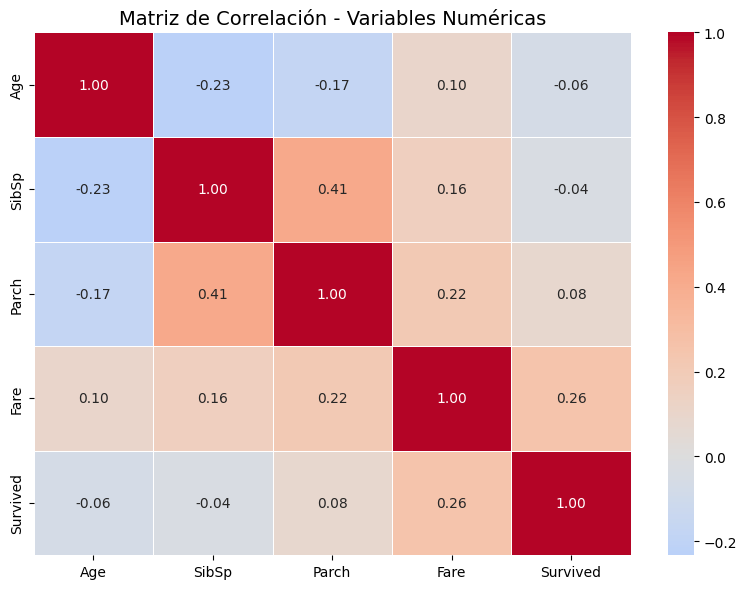

In [ ]:
# Matriz de correlación entre variables numéricas
columns_to_analyze = ['Age', 'SibSp', 'Parch', 'Fare', 'Survived']

plt.figure(figsize=(8, 6))

correlacion = df[columns_to_analyze].corr()

sns.heatmap(correlacion,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 10})

plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

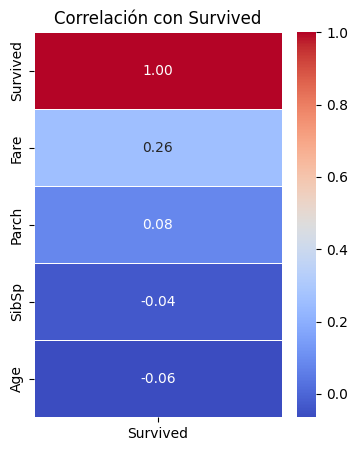

In [ ]:
# Correlación de cada variable con Survived
df_corr = df.copy()

# Calculamos la matriz de correlación
corr_matrix = df_corr[['Age', 'SibSp', 'Parch', 'Fare', 'Survived']].corr()

# Extraemos solo la correlación con Survived
target_variable = 'Survived'
target_corr = corr_matrix[[target_variable]].sort_values(by=target_variable, ascending=False)

# Graficamos
plt.figure(figsize=(4, 5))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'Correlación con {target_variable}')
plt.show()

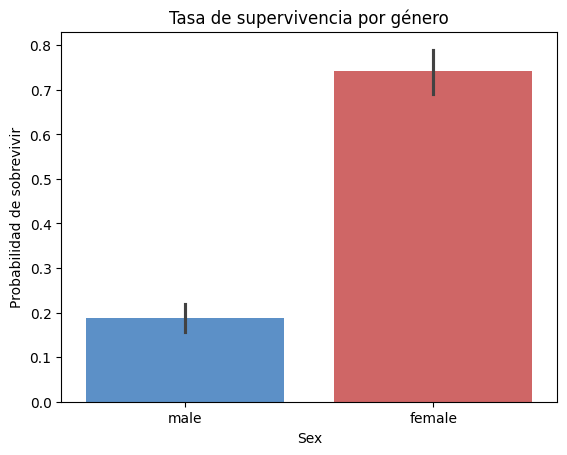

In [ ]:
# Supervivencia por género
sns.barplot(x='Sex', y='Survived', data=df, palette=['#4a90d9', '#e05555'])
plt.title('Tasa de supervivencia por género')
plt.ylabel('Probabilidad de sobrevivir')
plt.show()

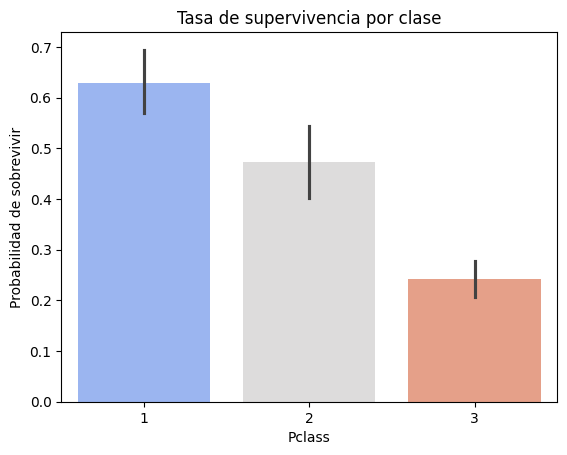

In [ ]:
# Supervivencia por clase
sns.barplot(x='Pclass', y='Survived', data=df, palette='coolwarm')
plt.title('Tasa de supervivencia por clase')
plt.ylabel('Probabilidad de sobrevivir')
plt.show()

Chequear si existen outliers en las variables. En caso de que existan, definir un criterio para eliminarlos si corresponde.

In [ ]:
# Detectamos outliers con el método IQR
print("=== Outliers por variable ===\n")

columns_to_analyze = ['Age', 'SibSp', 'Parch', 'Fare']

for col in columns_to_analyze:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

=== Outliers por variable ===

Age: 66 outliers (7.41%)
SibSp: 46 outliers (5.16%)
Parch: 213 outliers (23.91%)
Fare: 116 outliers (13.02%)


En este dataset no conviene eliminar ningún outlier porque:

Son valores reales, no errores de carga
Representan información importante para predecir supervivencia
Eliminarlos haría perder información clave   "Se analizaron los outliers mediante el método IQR. Se encontraron valores atípicos en todas las variables numéricas, siendo Parch la más afectada con 23.91%. Sin embargo se decidió no eliminarlos ya que representan información real y válida — familias numerosas, bebés, ancianos y pasajes de primera clase — que puede ser relevante para predecir la supervivencia."

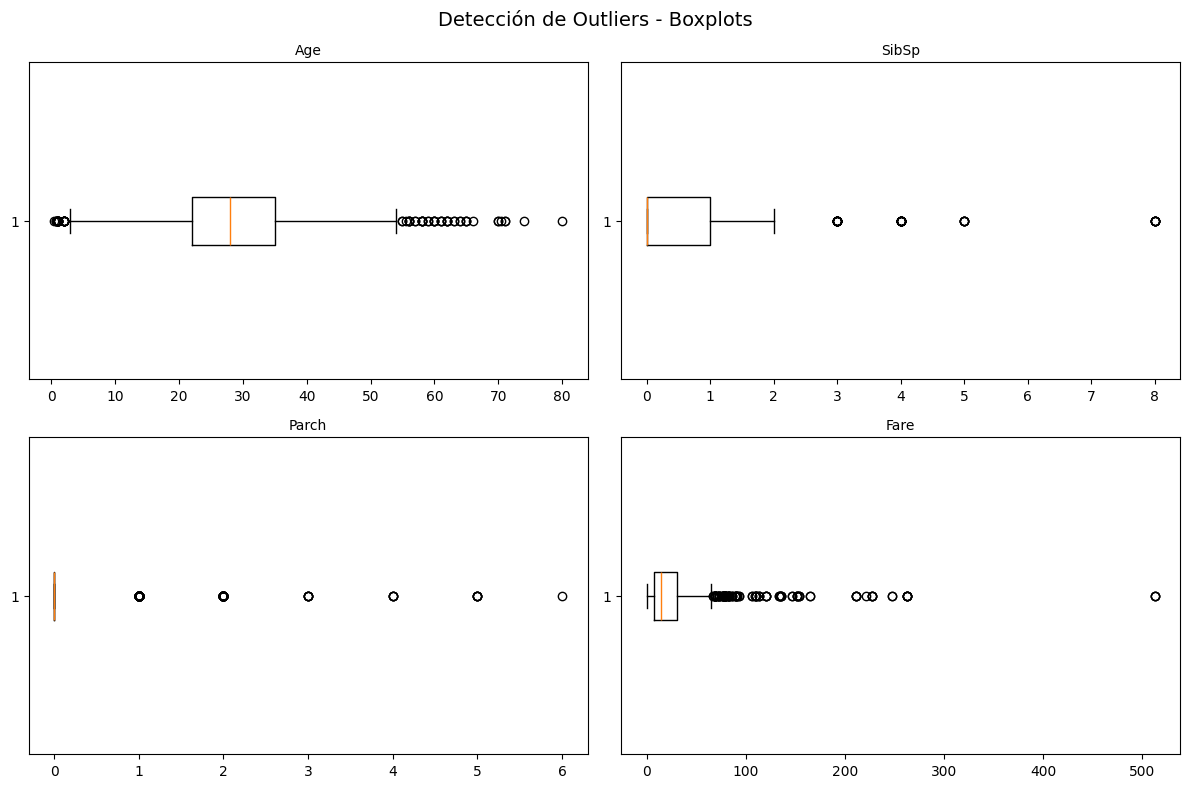

In [ ]:
# Boxplots para visualizar outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(columns_to_analyze):
    axes[i].boxplot(df[col], vert=False)
    axes[i].set_title(col, fontsize=10)

plt.suptitle('Detección de Outliers - Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

Separacion del modelo 80% / 20%

In [ ]:
# Separamos variable objetivo de las variables independientes
X = df.drop(columns=['Survived'])
y = df['Survived']

# Separamos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total de datos: {len(df)}")
print(f"Entrenamiento: {len(X_train)} filas ({len(X_train)/len(df)*100:.0f}%)")
print(f"Prueba:        {len(X_test)} filas ({len(X_test)/len(df)*100:.0f}%)")

Total de datos: 891
Entrenamiento: 712 filas (80%)
Prueba:        179 filas (20%)


transformación de variables categóricas

In [ ]:
# OneHotEncoding para variables categóricas
X_train = pd.get_dummies(X_train, columns=['Sex', 'Embarked'])
X_test = pd.get_dummies(X_test, columns=['Sex', 'Embarked'])

print("Columnas después de la transformación:")
print(X_train.columns.tolist())
print(f"\nNueva forma de X_train: {X_train.shape}")

Columnas después de la transformación:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']

Nueva forma de X_train: (712, 10)


# Estandarizamos las variables

In [ ]:
# Estandarizamos las variables
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Estandarización completada")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Estandarización completada
X_train shape: (712, 10)
X_test shape: (179, 10)


Entrenamos la red neuronal de clasificación

In [ ]:

modelo = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [ ]:
# Verificamos si hay sobreajuste
print(f"\nAccuracy entrenamiento: {modelo.score(X_train, y_train):.4f}")
print(f"Accuracy prueba:        {modelo.score(X_test, y_test):.4f}")


Accuracy entrenamiento: 0.8904
Accuracy prueba:        0.8268


examen final con grid serch Exponer los resultados del modelo.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import multiprocessing

# Espacio de búsqueda de hiperparámetros
param_distributions = {
    'hidden_layer_sizes': [(50,), (100,), (64, 32), (100, 50)],
    'alpha': np.logspace(-3, 1, 7),
    'learning_rate_init': [0.001, 0.01],
    'solver': ['adam']
}

# Modelo base
modelo_base = MLPClassifier(max_iter=500, random_state=42, early_stopping=True)

# Búsqueda aleatoria
grid = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='accuracy',
    n_jobs=multiprocessing.cpu_count() - 1,
    cv=4,
    random_state=42,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nMejores hiperparámetros encontrados:")
print(grid.best_params_)
print(f"\nMejor accuracy en validación: {grid.best_score_:.4f}")

Fitting 4 folds for each of 20 candidates, totalling 80 fits

Mejores hiperparámetros encontrados:
{'solver': 'adam', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (64, 32), 'alpha': np.float64(0.001)}

Mejor accuracy en validación: 0.8076


Accuracy entrenamiento: 0.8385
Accuracy prueba:        0.8212

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       105
           1       0.85      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



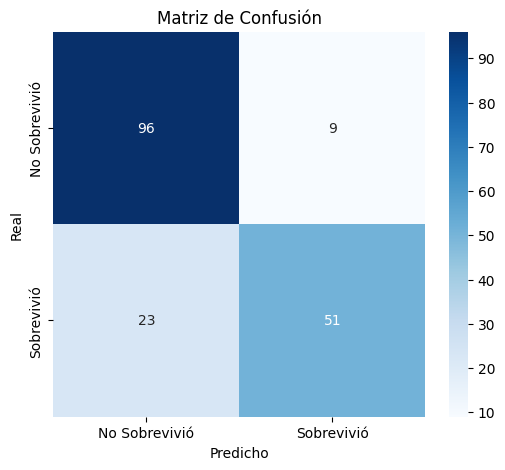

In [ ]:
# Predicciones con el mejor modelo
y_pred = grid.predict(X_test)

# Comparamos train vs test
print(f"Accuracy entrenamiento: {grid.score(X_train, y_train):.4f}")
print(f"Accuracy prueba:        {grid.score(X_test, y_test):.4f}")

# Reporte de clasificación
print("\n=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Sobrevivió', 'Sobrevivió'],
            yticklabels=['No Sobrevivió', 'Sobrevivió'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

In [ ]:
# Tabla con los resultados de todas las combinaciones probadas
resultados = pd.DataFrame(grid.cv_results_)
resultados.filter(regex='(param.*|mean_t|std_t)')\
    .drop(columns='params')\
    .sort_values('mean_test_score', ascending=False)\
    .head(10)

,param_solver,param_learning_rate_init,param_hidden_layer_sizes,param_alpha,mean_test_score,std_test_score
1,adam,0.010,"(64, 32)",0.001000,0.807584,0.045878
3,adam,0.010,"(64, 32)",0.004642,0.807584,0.045532
15,adam,0.010,"(50,)",0.021544,0.807584,0.043585
2,adam,0.010,"(50,)",0.464159,0.804775,0.037345
19,adam,0.010,"(100,)",0.100000,0.796348,0.047400
4,adam,0.010,"(100,)",0.021544,0.794944,0.048572
11,adam,0.010,"(100,)",0.001000,0.793539,0.049835
5,adam,0.001,"(100,)",10.000000,0.778090,0.032395
18,adam,0.010,"(50,)",2.154435,0.778090,0.055116
17,adam,0.001,"(64, 32)",0.001000,0.776685,0.013975


In [ ]:
# Mostramos el resumen final del modelo optimizado
mejor_modelo = grid.best_estimator_

y_pred_train = mejor_modelo.predict(X_train)
y_pred_test = mejor_modelo.predict(X_test)

print("=== Resumen Final del Modelo ===\n")
print(f"Train Score:  {mejor_modelo.score(X_train, y_train) * 100}")
print(f"Test Score:   {mejor_modelo.score(X_test, y_test) * 100}")
print(f"Accuracy:     {accuracy_score(y_test, y_pred_test) * 100}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report")
print(classification_report(y_test, y_pred_test))

=== Resumen Final del Modelo ===

Train Score:  83.84831460674157
Test Score:   82.12290502793296
Accuracy:     82.12290502793296

Confusion Matrix:
[[96  9]
 [23 51]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       105
           1       0.85      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



El modelo utilizado fue una Red Neuronal MLP (Multilayer Perceptron) de clasificación. Para encontrar los mejores hiperparámetros se utilizó RandomizedSearchCV, que probó 20 combinaciones distintas con validación cruzada de 4 folds.
Los hiperparámetros elegidos fueron:

hidden_layer_sizes=(64, 32): dos capas ocultas con 64 y 32 neuronas. La red va reduciendo neuronas para ir comprimiendo la información aprendida.
alpha=0.001: regularización L2 que evita que el modelo memorice los datos de entrenamiento.
learning_rate_init=0.01: tasa de aprendizaje que controla qué tan rápido ajusta sus pesos el modelo.
solver=adam: optimizador eficiente que adapta la tasa de aprendizaje durante el entrenamiento.

Resultados obtenidos:

Train Score: 83.84%
Test Score: 82.12%

La diferencia entre Train Score y Test Score es de solo 1.7%, lo que confirma que el modelo no presenta sobreajuste y generaliza correctamente para predecir la supervivencia de nuevos pasajeros.